# Econometrics of marketing: Kaggle project

### Reminder:

We want to predict the variable `price` hence we will use this cost function as a score of our predictions:

RMSE = $\sqrt{\mathrm{SCR}} = \sqrt{\displaystyle \frac{1}{n}  \sum_{i = 1}^{n}(y_i - \hat{y}_i)^2}$

# Pre-requisites

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

import re
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

#Distances:
from geopy.distance import great_circle

#Metrics:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, Normalizer
from sklearn.metrics import mean_squared_error

#LASSO:
from sklearn.linear_model import Lasso
from sklearn.linear_model import lasso_path
from sklearn.linear_model import LassoCV
import matplotlib.cm as cm

#Linear regression:
import statsmodels.api as sm

#Statistics:
import statsmodels
import statsmodels.api as sm
from scipy.stats import norm
from catboost import Pool, CatBoostRegressor

# 1 Import the data

In [2]:
my_path = "/Users/brunopilarczyk/Documents/Cours/M2 Stat Eco/S1/Econometrics of Marketing/Kaggle project/tsem2stateco2019/"

In [3]:
train = pd.read_csv(my_path+"train_airbnb.csv")
test = pd.read_csv(my_path+"test_airbnb.csv")
submit_template = pd.read_csv(my_path+"submission_airbnb.csv")
pd.set_option('display.max_columns', 300) #we want to show loads of columns: 57 features + 1 label = 58
pd.set_option('display.max_rows', 300) #we want to show loads of rows

In [4]:
#checking the shape
print(train.shape)

#checking the potential duplicates
print(format(train.duplicated().sum()))

(44197, 58)
0


In [5]:
#Having a look at the types:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44197 entries, 0 to 44196
Data columns (total 58 columns):
id                             44197 non-null int64
name                           44196 non-null object
description                    44193 non-null object
neighborhood_overview          26264 non-null object
notes                          13978 non-null object
transit                        28175 non-null object
access                         22322 non-null object
interaction                    21072 non-null object
house_rules                    23459 non-null object
host_id                        44197 non-null int64
host_since                     44187 non-null object
host_seniority                 44187 non-null float64
host_response_time             29448 non-null object
host_response_rate             29448 non-null float64
host_listings_count            44187 non-null float64
host_verifications             44161 non-null object
neighbourhood_cleansed         44197 non-n

In [6]:
train.head()

,id,name,description,neighborhood_overview,notes,transit,access,interaction,house_rules,host_id,host_since,host_seniority,host_response_time,host_response_rate,host_listings_count,host_verifications,neighbourhood_cleansed,city,zipcode,country,latitude_airbnb,longitude_airbnb,property_type,room_type,accommodates,bathrooms,bedrooms,beds,bed_type,amenities,price,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,calendar_updated,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,cancellation_policy,reviews_per_month,geolocation,features,geopoint_announce,department
0,10534791,Appartement 2P pour 4 pers. BERCY,Cet appartement est idéalement situé à 10 minu...,Le quartier est animé sans être étouffant. Il ...,NaN,Lignes de métro 6 et 8 à moins de 3 minutes. ...,Vous aurez accès à l'ensemble du logement.,NaN,NaN,22523453,2014-10-14T00:00:00.000Z,1805.0,NaN,NaN,1.0,"email,phone,reviews",Reuilly,Paris,75012.0,France,48.841013,2.392880,Apartment,Entire home/apt,4.0,1.0,1.0,2.0,Real Bed,"TV,Internet,Wireless Internet,Kitchen,Buzzer/w...",55.0,0_no_deposit,1_]0-30],1.0,0.0,3.0,1125.0,3 weeks ago,7.0,11.0,11.0,11.0,2.0,2016-03-30,2016-06-20,80.0,7.0,8.0,7.0,8.0,10.0,8.0,strict,0.16,"48.8410132928,2.39288035231",Host Has Profile Pic,POINT(2.3928803523142053 48.841013292835235),Paris
1,16001259,"Cosy 2 pièces in Paris 12ème, Porte Dorée","Mon logement est proche du bois de Vincennes, ...",NaN,NaN,NaN,NaN,NaN,NaN,37202116,2015-07-01T00:00:00.000Z,1545.0,NaN,NaN,1.0,phone,Reuilly,Paris,75012.0,France,48.840806,2.408244,Apartment,Entire home/apt,4.0,1.0,1.0,2.0,Real Bed,"TV,Wireless Internet,Kitchen,Smoking allowed,E...",53.0,0_no_deposit,0_no_deposit,1.0,0.0,7.0,14.0,5 months ago,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,flexible,NaN,"48.8408064183,2.40824414207",Host Has Profile Pic,POINT(2.4082441420748024 48.84080641832087),Paris
2,17763072,Charmant Studio Paris 11/12ème,Un studio cosy qui sera votre nid douillet lor...,"Le quartier est agréable, vivant et convivial ...",La TV est à l'ancienne donc les aficionados de...,Il est très bien situé puisque proche des stat...,À l'ensemble des fonctionnalités de l'appartem...,"Si mon emploi du temps le permet! Sinon, les i...",Je compte sur vous pour prendre soin de ce coc...,73025491,2016-05-20T00:00:00.000Z,1221.0,within an hour,100.0,1.0,"email,phone,linkedin,reviews,jumio,government_id",Reuilly,Paris,75012.0,France,48.848238,2.389146,Apartment,Entire home/apt,2.0,1.0,1.0,1.0,Real Bed,"TV,Wireless Internet,Kitchen,Heating,Essential...",50.0,1_]0-200],0_no_deposit,1.0,0.0,1.0,1125.0,2 days ago,3.0,13.0,26.0,91.0,2.0,2017-03-26,2017-03-27,70.0,9.0,6.0,10.0,10.0,9.0,8.0,moderate,2.00,"48.8482384171,2.38914645391","Host Has Profile Pic,Host Identity Verified",POINT(2.389146453908913 48.84823841713855),Paris
3,3469854,Chambre Seule au pied du métro !,Bonjour à tous!Vous serez les bienvenus à Char...,"Quartier calme, Proche des boutiques, des cent...",Couette et oreillers neufs. Chambre seul sur p...,métro Ligne 8 arrêt Liberté sortie coté rue du...,Sdb et WC à partagerWifi,"Nous sommes disponibles pour des conseils, mai...",Etant propriétaire je souhaiterai du calme.Cha...,17442654,2014-06-30T00:00:00.000Z,1911.0,NaN,NaN,1.0,"email,phone,reviews,jumio",Reuilly,Charenton-le-Pont,94220.0,France,48.829206,2.400398,Apartment,Private room,2.0,1.0,1.0,1.0,Couch,"Wireless Internet,Air conditioning,Free parkin...",45.0,0_no_deposit,1_]0-30],1.0,0.0,2.0,7.0,10 months ago,28.0,58.0,88.0,89.0,9.0,2014-07-09,2016-05-10,75.0,7.0,9.0,9.0,9.0,9.0,8.0,strict,0.27,"48.8292056677,2.40039774906","Host Has Profile Pic,Host Identity Verified,Is...",POINT(2.4003977490581687 48.82920566771778),Paris
4,8007685,Studio tout neuf et lumineux,"Studio récemment

# 2 Exploratory data analysis and preparation

Let's have a look at the distribution of the price, the dependent variable we have to be able to predict:

In [7]:
train = train[~train.price.isna()]

In [8]:
# Categorical variable price_range, it will help determining threshold or relevant variables
train["price_range"] = np.where(train.price > 200,
                               "+200",
                               np.where(train.price > 150,
                                       "150-200",
                                       np.where(train.price > 100,
                                               "100-150",
                                               np.where(train.price > 50,
                                                       "50-100",
                                                       "< 50"))))

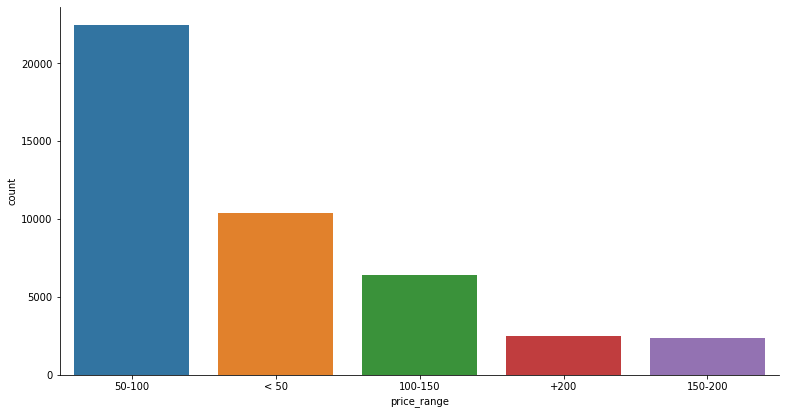

In [9]:
sns.catplot(x='price_range', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(12, 6)

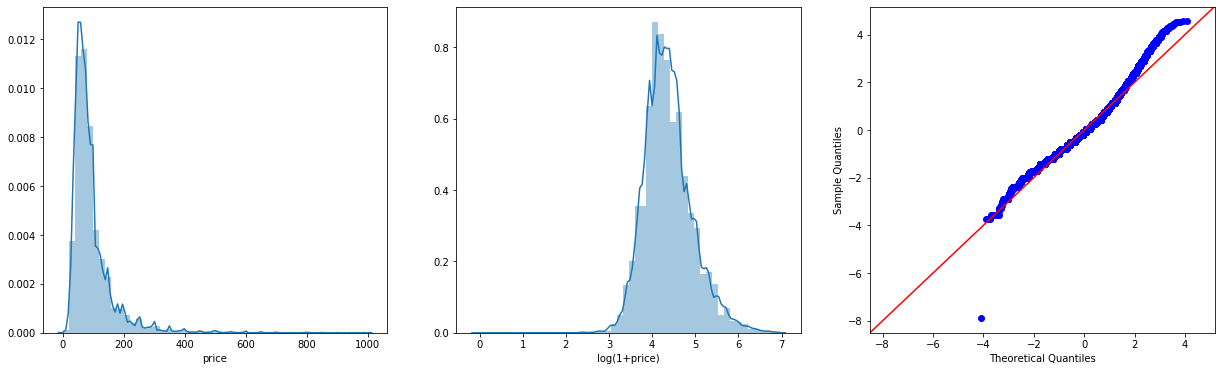

In [10]:
fig, axes = plt.subplots(1,3, figsize=(21,6))
sns.distplot(train['price'], ax=axes[0])
sns.distplot(np.log1p(train['price']), ax=axes[1])
axes[1].set_xlabel('log(1+price)')
sm.qqplot(np.log1p(train['price']), norm, fit=True, line='45', ax=axes[2]);

## 2.1 Dealing with NAs

In [11]:
train.isna().sum()

id                                 0
name                               1
description                        4
neighborhood_overview          17913
notes                          30196
transit                        16002
access                         21854
interaction                    23102
house_rules                    20718
host_id                            0
host_since                        10
host_seniority                    10
host_response_time             14739
host_response_rate             14739
host_listings_count               10
host_verifications                36
neighbourhood_cleansed             0
city                              23
zipcode                           11
country                            0
latitude_airbnb                    0
longitude_airbnb                   0
property_type                      0
room_type                          0
accommodates                       0
bathrooms                        138
bedrooms                          87
b

## 2.2 Score and categorical variables

### 2.2.1 `Features`

We can fill the NAs by the 2 most represented features in the train dataset

In [12]:
train['features'] = train['features'].fillna("Host Has Profile Pic,Is Location Exact")
test['features'] = test['features'].fillna("Host Has Profile Pic,Is Location Exact")

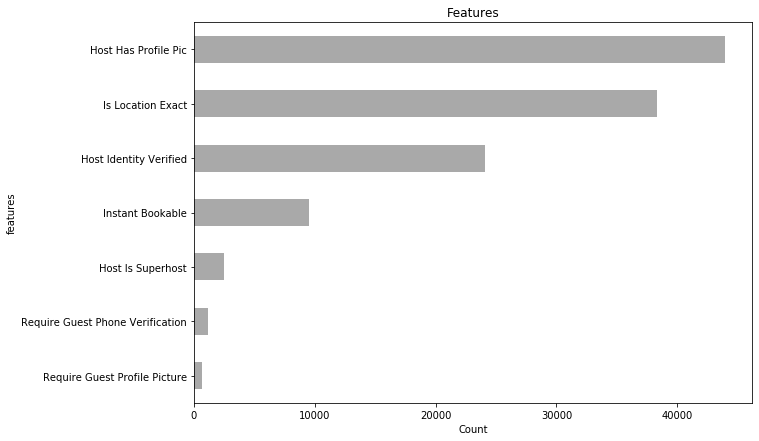

In [13]:
from collections import Counter

results = Counter()
train['features'].str.strip('{}')\
               .str.replace('"', '')\
               .str.lstrip('\"')\
               .str.rstrip('\"')\
               .str.split(',')\
               .apply(results.update)

results.most_common(30)

#new df
sub_df_features = pd.DataFrame(results.most_common(30), columns=['features', 'count'])

#top
sub_df_features.sort_values(by=['count'], ascending=True).plot(kind='barh', x='features', y='count',  
                                                      figsize=(10,7), legend=False, color='darkgrey',
                                                      title='Features')
plt.xlabel('Count');

In [14]:
#train:
#Changing features column into a string:
train["features"] = train["features"].astype(str)
#We create a score for features
train['features_score'] = train['features'].str.count(',') + 1

#test:
#Changing features column into a string:
test["features"] = test["features"].astype(str)
#We create a score for features
test['features_score'] = test['features'].str.count(',') + 1

In [15]:
corr = train[['features_score', 'price']].corr()
corr.style.background_gradient(cmap='viridis')

,features_score,price
features_score,1,0.101706
price,0.101706,1


### 2.2.3 amenities

We can fill the NAs by the 3 most represented amenities in the train dataset.

In [16]:
#train:
train['amenities'] = train['amenities'].fillna("Kitchen, Heating, Wireless Internet")

#test:
test['amenities'] = test['amenities'].fillna("Kitchen, Heating, Wireless Internet")

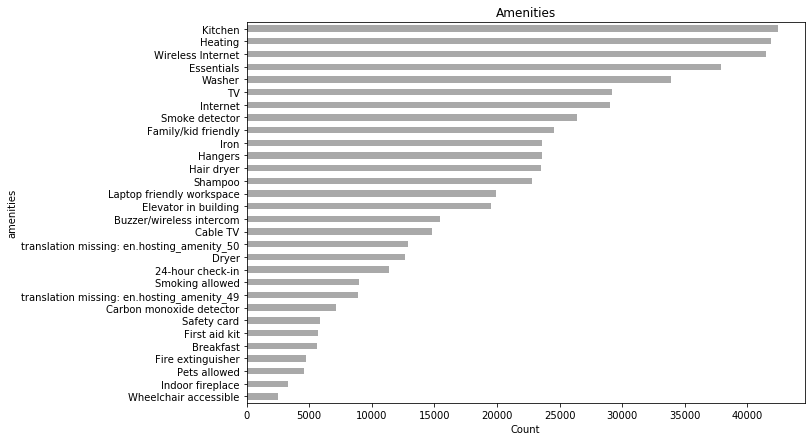

In [17]:
from collections import Counter

results = Counter()
train['amenities'].str.strip('{}')\
               .str.replace('"', '')\
               .str.lstrip('\"')\
               .str.rstrip('\"')\
               .str.split(',')\
               .apply(results.update)

results.most_common(30)

#new df
sub_df = pd.DataFrame(results.most_common(30), columns=['amenities', 'count'])

#top
sub_df.sort_values(by=['count'], ascending=True).plot(kind='barh', x='amenities', y='count',  
                                                      figsize=(10,7), legend=False, color='darkgrey',
                                                      title='Amenities')
plt.xlabel('Count');

Let us retain some few amenities where we can easily see breakpoints:

In [18]:
amenities_word = ['Essentials', 'Iron', 'Cable TV', 'Dryer', 'Laptop friendly workspace']

In [19]:
for word in amenities_word:
    train[word] = np.where(train["amenities"].str.contains(word), 1, 0)
    test[word] = np.where(test["amenities"].str.contains(word), 1, 0)

### 2.2.4  `bed_type`

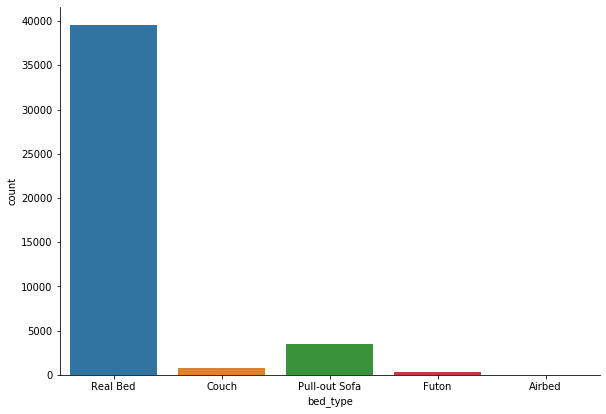

In [20]:
sns.catplot(x='bed_type', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(9, 6)

In [21]:
#train:
train["bed_type"] = train["bed_type"].fillna("Real Bed")

train["Real_Bed"] = np.where(train["bed_type"] == "Real Bed", 1, 0)
train["Pull-out_Sofa"] = np.where(train["bed_type"] == "Pull-out Sofa", 1, 0)

#test:
test["bed_type"] = test["bed_type"].fillna("Real Bed")

test["Real_Bed"] = np.where(test["bed_type"] == "Real Bed", 1, 0)
test["Pull-out_Sofa"] = np.where(test["bed_type"] == "Pull-out Sofa", 1, 0)

In [22]:
corr = train[['Real_Bed', 'Pull-out_Sofa', 'price']].corr()
corr.style.background_gradient(cmap='viridis')

,Real_Bed,Pull-out_Sofa,price
Real_Bed,1,-0.861628,0.155941
Pull-out_Sofa,-0.861628,1,-0.133254
price,0.155941,-0.133254,1


### 2.2.5 property_type

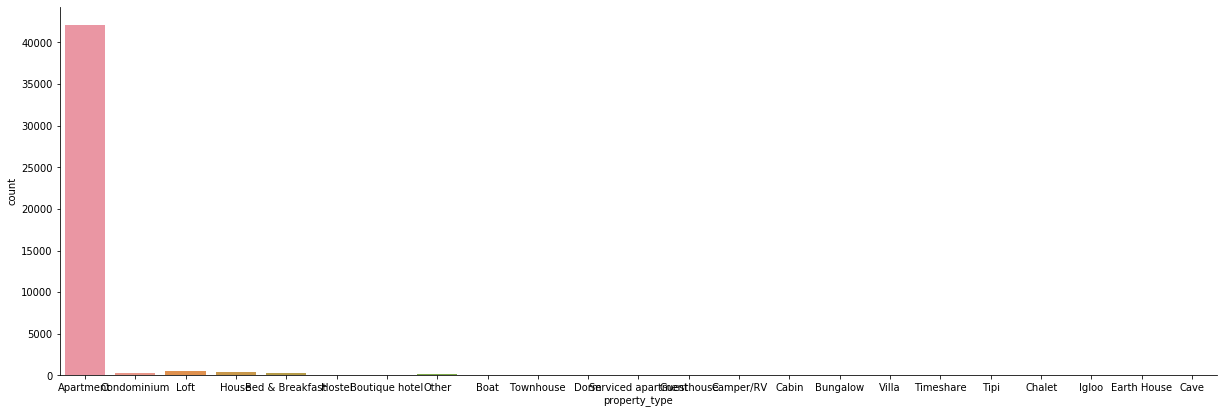

In [23]:
sns.catplot(x='property_type', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(20, 6)

In [24]:
pd.crosstab(train.property_type, train.price_range)

price_range,+200,100-150,150-200,50-100,< 50
property_type,,,,,
Apartment,2253,6021,2182,21772,9928
Bed & Breakfast,31,38,23,156,79
Boat,7,6,5,4,2
Boutique hotel,12,31,14,35,6
Bungalow,0,0,0,2,0
Cabin,1,0,2,6,4
Camper/RV,1,0,0,1,0
Cave,0,0,0,0,2
Chalet,1,0,0,0,0


We can create a dummy variable for houses or lofts and for apartments:

In [25]:
#train:
train["Apartment"] = np.where(train["property_type"] == "Apartment", 1, 0 )
train["House_Loft"] = np.where(train["property_type"].isin(["House", "Loft"]), 1, 0 )

#test:
test["Apartment"] = np.where(test["property_type"] == "Apartment", 1, 0 )
test["House_Loft"] = np.where(test["property_type"].isin(["House", "Loft"]), 1, 0 )

In [26]:
corr = train[['Apartment', 'House_Loft', 'price']].corr()
corr.style.background_gradient(cmap='viridis')

,Apartment,House_Loft,price
Apartment,1,-0.671721,-0.086132
House_Loft,-0.671721,1,0.104609
price,-0.086132,0.104609,1


### 2.2.6 `room_type`

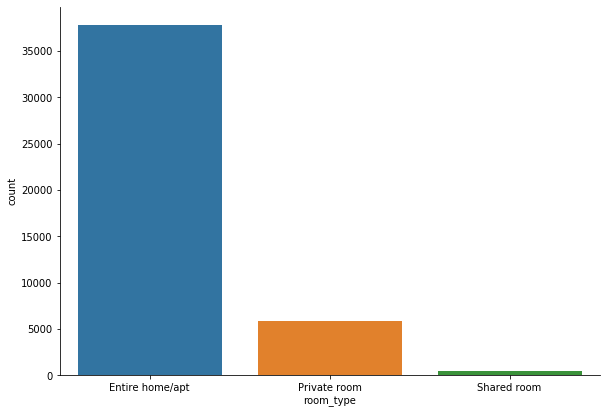

In [27]:
sns.catplot(x='room_type', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(9, 6)

In [28]:
#train:
train["room_type"] = train["room_type"].fillna("Entire home/apt")

for word in train["room_type"].unique():
    train[word] = np.where(train["room_type"].str.contains(word), 1, 0)

#test:
test["room_type"] = test["room_type"].fillna("Entire home/apt")

for word in test["room_type"].unique():
    test[word] = np.where(test["room_type"].str.contains(word), 1, 0)

In [29]:
corr = train[['Entire home/apt', 'Private room', 'Shared room','price']].corr()
corr.style.background_gradient(cmap='viridis')

,Entire home/apt,Private room,Shared room,price
Entire home/apt,1,-0.956513,-0.252957,0.206751
Private room,-0.956513,1,-0.0402472,-0.190443
Shared room,-0.252957,-0.0402472,1,-0.0765703
price,0.206751,-0.190443,-0.0765703,1


### 2.2.7 Cancellation policy

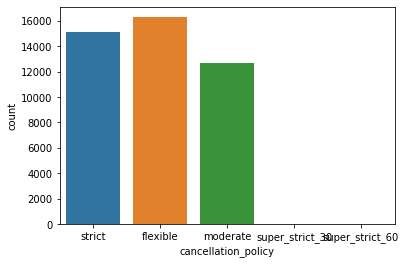

In [30]:
sns.countplot(x = "cancellation_policy", data = train )

In [31]:
#train:
train["cancellation_policy"] = train["cancellation_policy"].fillna("flexible")

train["flexible"] = np.where(train["cancellation_policy"] == "flexible", 1, 0)
train["moderate"] = np.where(train["cancellation_policy"] == "moderate", 1, 0)
train["strict"] = np.where(train["cancellation_policy"] == "strict", 1, 0)

#test:
test["cancellation_policy"] = test["cancellation_policy"].fillna("flexible")

test["flexible"] = np.where(test["cancellation_policy"] == "flexible", 1, 0)
test["moderate"] = np.where(test["cancellation_policy"] == "moderate", 1, 0)
test["strict"] = np.where(test["cancellation_policy"] == "strict", 1, 0)

In [32]:
corr = train[['flexible', 'moderate','strict', 'price']].corr()
corr.style.background_gradient(cmap='viridis')

,flexible,moderate,strict,price
flexible,1,-0.485966,-0.552894,-0.137407
moderate,-0.485966,1,-0.459082,-0.0705469
strict,-0.552894,-0.459082,1,0.205501
price,-0.137407,-0.0705469,0.205501,1


### 2.2.8 `neighbourhood_cleansed`

In [33]:
train.neighbourhood_cleansed.isna().sum()

0

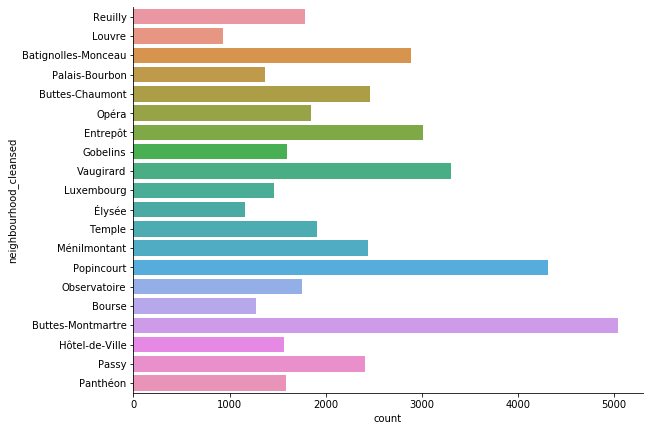

In [34]:
sns.catplot(y='neighbourhood_cleansed', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [35]:
#train:
for word in train['neighbourhood_cleansed'].unique():
    train[word] = np.where(train['neighbourhood_cleansed'].str.contains(word), 1, 0)

#test:
for word in test['neighbourhood_cleansed'].unique():
    test[word] = np.where(test['neighbourhood_cleansed'].str.contains(word), 1, 0)

In [36]:
train['neighbourhood_cleansed'].unique()

array(['Reuilly', 'Louvre', 'Batignolles-Monceau', 'Palais-Bourbon',
       'Buttes-Chaumont', 'Opéra', 'Entrepôt', 'Gobelins', 'Vaugirard',
       'Luxembourg', 'Élysée', 'Temple', 'Ménilmontant', 'Popincourt',
       'Observatoire', 'Bourse', 'Buttes-Montmartre', 'Hôtel-de-Ville',
       'Passy', 'Panthéon'], dtype=object)

### 2.2.9 `security_deposit`

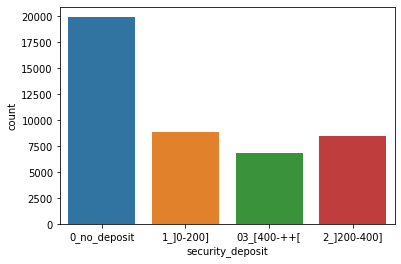

In [37]:
sns.countplot(train["security_deposit"])

In [38]:
pd.crosstab(train.security_deposit, train.price_range)

price_range,+200,100-150,150-200,50-100,< 50
security_deposit,,,,,
03_[400-++[,872,1589,789,2946,642
0_no_deposit,1286,2341,865,9724,5724
1_]0-200],84,839,164,5047,2733
2_]200-400],279,1627,537,4779,1286


In [39]:
#train:
#Changing security_deposit variable into string:
train["security_deposit"] = train["security_deposit"].astype(str)
train["security_deposit"] = train["security_deposit"].fillna("0_no_deposit")

#We create a score for security_deposit:
train['secu_score'] = np.where(train["security_deposit"].isin(["0_no_deposit", "1_]0-200]", "2_]200-400]"]), 0, 1)

#test:
#Changing security_deposit variable into string:
test["security_deposit"] = test["security_deposit"].astype(str)
test["security_deposit"] = test["security_deposit"].fillna("0_no_deposit")

#We create a score for security_deposit:
test['secu_score'] = np.where(test["security_deposit"].isin(["0_no_deposit", "1_]0-200]", "2_]200-400]"]), 0, 1)

In [40]:
corr = train[["secu_score","price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,secu_score,price
secu_score,1,0.19121
price,0.19121,1


### 2.2.10 `cleaning_fee`

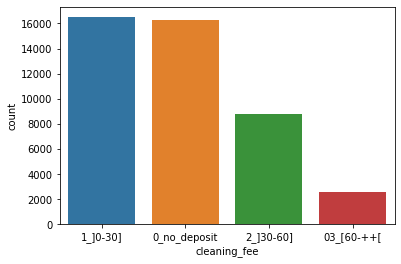

In [41]:
sns.countplot(train["cleaning_fee"])

In [42]:
pd.crosstab(train.cleaning_fee, train.price_range)

price_range,+200,100-150,150-200,50-100,< 50
cleaning_fee,,,,,
03_[60-++[,997,582,517,400,33
0_no_deposit,807,1837,650,8003,4999
1_]0-30],112,1447,253,9950,4761
2_]30-60],605,2530,935,4143,592


In [43]:
#train:
#Changing cleaning_fee variable into string:
train["cleaning_fee"] = train["cleaning_fee"].astype(str)
train["cleaning_fee"] = train["cleaning_fee"].fillna("1_]0-30]")


#We create a score for cleaning_fee
train['clean_score'] = np.where(train["cleaning_fee"].isin(["0_no_deposit", "1_]0-30]", "2_]30-60]"]), 0, 1)


#test:
#Changing cleaning_fee variable into string:
test["cleaning_fee"] = test["cleaning_fee"].astype(str)
test["cleaning_fee"] = test["cleaning_fee"].fillna("1_]0-30]")

#We create a score for cleaning_fee
test['clean_score'] = np.where(test["cleaning_fee"].isin(["0_no_deposit", "1_]0-30]", "2_]30-60]"]), 0, 1)

In [44]:
corr = train[["clean_score","price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,clean_score,price
clean_score,1,0.406864
price,0.406864,1


## 2.3 Quantitative variables

### 2.3.1 `beds`

In [45]:
train.beds.describe()

count    44097.000000
mean         1.674105
std          1.019245
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         16.000000
Name: beds, dtype: float64

In [46]:
#train:
train["beds"] = train["beds"].fillna(1)

#test:
test["beds"] = test["beds"].fillna(1)

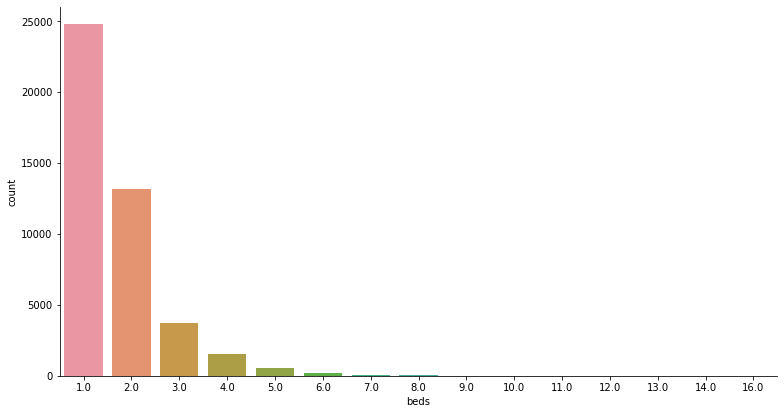

In [47]:
sns.catplot(x='beds', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [48]:
#train:
train["one_bed"] = np.where(train["beds"] == 1, 1, 0)

#train:
test["one_bed"] = np.where(test["beds"] == 1, 1, 0)

In [49]:
corr = train[["beds", "one_bed", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,beds,one_bed,price
beds,1,-0.747223,0.503327
one_bed,-0.747223,1,-0.367844
price,0.503327,-0.367844,1


### 2.3.2 `bathrooms`

In [50]:
train.bathrooms.describe()

count    44015.000000
mean         1.091037
std          0.371737
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: bathrooms, dtype: float64

In [51]:
#train:
train["bathrooms"] = train["bathrooms"].fillna(1)

#test:
test["bathrooms"] = test["bathrooms"].fillna(1)

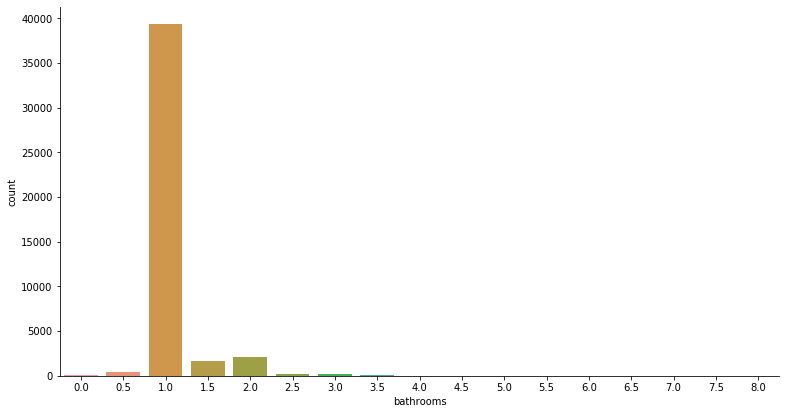

In [52]:
sns.catplot(x='bathrooms', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [53]:
#train:
train["one_bath"] = np.where(train["bathrooms"] == 1, 1, 0)

#train:
test["one_bath"] = np.where(test["bathrooms"] == 1, 1, 0)

In [54]:
corr = train[["bathrooms", "one_bath", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,bathrooms,one_bath,price
bathrooms,1,-0.69778,0.464756
one_bath,-0.69778,1,-0.413552
price,0.464756,-0.413552,1


### 2.3.3 accommodates

In [55]:
train.accommodates.describe()

count    44153.000000
mean         3.021425
std          1.458877
min          1.000000
25%          2.000000
50%          2.000000
75%          4.000000
max         16.000000
Name: accommodates, dtype: float64

In [56]:
#train:
train["accommodates"] = train["accommodates"].fillna(2)

#test:
test["accommodates"] = test["accommodates"].fillna(2)

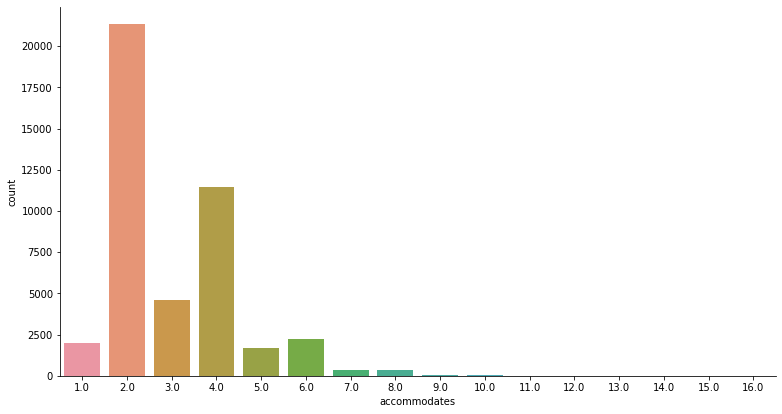

In [57]:
sns.catplot(x='accommodates', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [58]:
pd.crosstab(train.accommodates, train.price_range)

price_range,+200,100-150,150-200,50-100,< 50
accommodates,,,,,
1.0,10,37,8,471,1437
2.0,171,1571,325,11839,7406
3.0,90,682,178,2892,739
4.0,724,2714,940,6364,723
5.0,310,579,301,489,29
6.0,706,661,452,393,39
7.0,158,88,61,24,4
8.0,205,51,72,15,6
9.0,42,5,9,5,1


In [59]:
#train:
train["low_acco"] = np.where(train["accommodates"] < 3, 1, 0)
train["high_acco"] = np.where(train["accommodates"] > 5, 1, 0)

#test:
test["low_acco"] = np.where(test["accommodates"] < 3, 1, 0)
test["high_acco"] = np.where(test["accommodates"] > 5, 1, 0)

In [60]:
#train:
train["accommodates"] = np.log1p(train["accommodates"])

#test:
test["accommodates"] = np.log1p(test["accommodates"])

In [61]:
corr = train[["accommodates", "low_acco", "high_acco", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,accommodates,low_acco,high_acco,price
accommodates,1,-0.870419,0.574867,0.533003
low_acco,-0.870419,1,-0.291347,-0.389356
high_acco,0.574867,-0.291347,1,0.462768
price,0.533003,-0.389356,0.462768,1


In [62]:
#train:
train["accommodates"] = np.log1p(train["accommodates"])

#test:
test["accommodates"] = np.log1p(test["accommodates"])

### 2.3.4 `bedrooms`

In [63]:
train.bedrooms.describe()

count    44066.000000
mean         1.047088
std          0.791812
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: bedrooms, dtype: float64

In [64]:
#train:
train["bedrooms"] = train["bedrooms"].fillna(1)

#test:
test["bedrooms"] = test["bedrooms"].fillna(1)

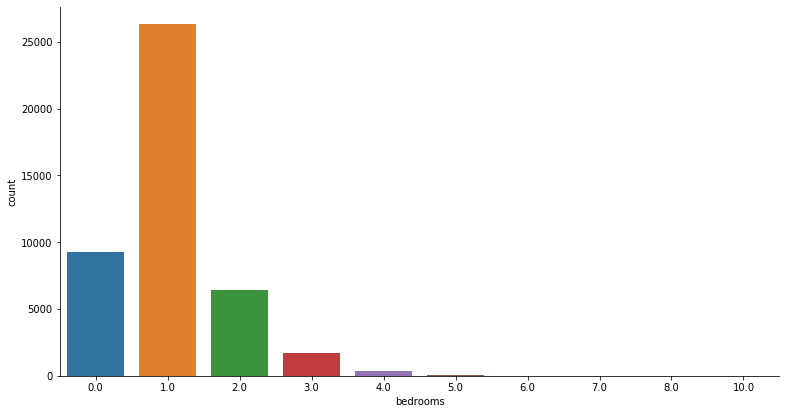

In [65]:
sns.catplot(x='bedrooms', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [66]:
pd.crosstab(train["bedrooms"], train["price_range"])

price_range,+200,100-150,150-200,50-100,< 50
bedrooms,,,,,
0.0,37,517,73,5194,3449
1.0,418,3465,933,14781,6707
2.0,1034,1940,915,2305,212
3.0,705,422,370,196,14
4.0,251,42,60,19,2
5.0,57,10,4,1,0
6.0,15,0,0,0,0
7.0,1,0,0,0,0
8.0,1,0,0,0,0


In [67]:
#train:
train["one_bedroom"] = np.where(train["bedrooms"] == 1, 1, 0)

#test:
test["one_bedroom"] = np.where(test["bedrooms"] == 1, 1, 0)

In [68]:
corr = train[["bedrooms", "one_bedroom", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,bedrooms,one_bedroom,price
bedrooms,1,-0.0721226,0.5445
one_bedroom,-0.0721226,1,-0.235293
price,0.5445,-0.235293,1


### 2.3.5 `minimum_nights`

In [69]:
train.minimum_nights.describe()

count    44153.000000
mean         3.382352
std         11.551155
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1000.000000
Name: minimum_nights, dtype: float64

Text(0, 0.5, 'count')

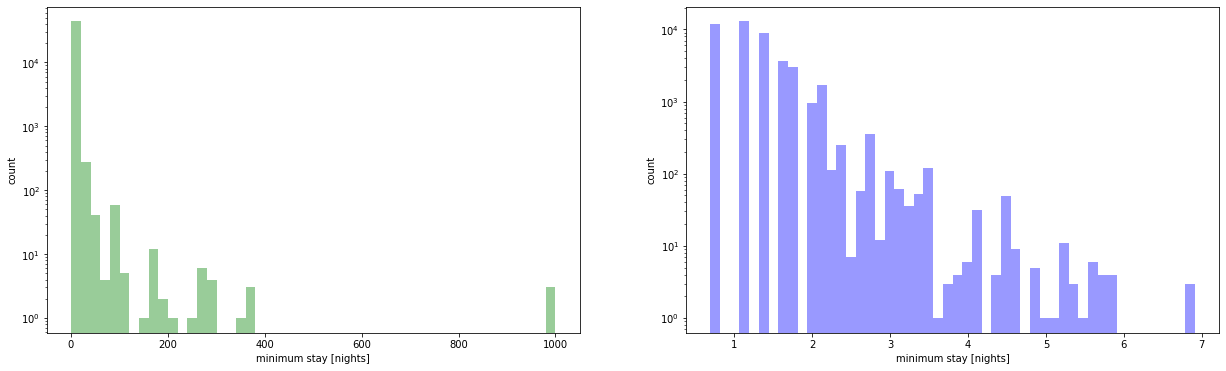

In [70]:
fig, axes = plt.subplots(1,2, figsize=(21, 6))

sns.distplot(train['minimum_nights'], rug=False, kde=False, color="green", ax = axes[0])
axes[0].set_yscale('log')
axes[0].set_xlabel('minimum stay [nights]')
axes[0].set_ylabel('count')

sns.distplot(np.log1p(train['minimum_nights']), rug=False, kde=False, color="blue", ax = axes[1])
axes[1].set_yscale('log')
axes[1].set_xlabel('minimum stay [nights]')
axes[1].set_ylabel('count')

In [71]:
#train:
train["minimum_nights"] = train["minimum_nights"].fillna(2)

#test:
test["minimum_nights"] = test["minimum_nights"].fillna(2)

In [72]:
pd.crosstab(train[train.minimum_nights < 10].minimum_nights, train[train.minimum_nights < 10].price_range)

price_range,+200,100-150,150-200,50-100,< 50
minimum_nights,,,,,
1.0,391,1282,374,6202,3536
2.0,457,1710,542,7229,2958
3.0,701,1601,687,4380,1550
4.0,323,694,285,1692,621
5.0,358,535,251,1278,553
6.0,70,144,59,462,235
7.0,176,284,109,733,377
8.0,2,7,3,38,42
9.0,1,4,3,9,4


In [73]:
#train:
train["minimum_nights"] = np.log1p(train["minimum_nights"])

#test:
test["minimum_nights"] = np.log1p(test["minimum_nights"])

In [74]:
corr = train[["minimum_nights", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,minimum_nights,price
minimum_nights,1,0.0970662
price,0.0970662,1


### 2.3.7 `guests_included`

In [75]:
train.guests_included.describe()

count    44153.000000
mean         1.377551
std          0.861361
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: guests_included, dtype: float64

In [76]:
#train:
train["guests_included"] = train["guests_included"].fillna(1)

#test:
test["guests_included"] = test["guests_included"].fillna(1)

In [77]:
pd.crosstab(train.guests_included, train.price_range)

price_range,+200,100-150,150-200,50-100,< 50
guests_included,,,,,
1.0,1746,4205,1613,16622,9232
2.0,156,1395,325,4963,1086
3.0,50,178,58,436,45
4.0,288,490,269,425,18
5.0,69,81,47,35,1
6.0,151,40,35,10,1
7.0,13,5,6,0,0
8.0,30,2,2,1,0
9.0,7,0,0,0,0


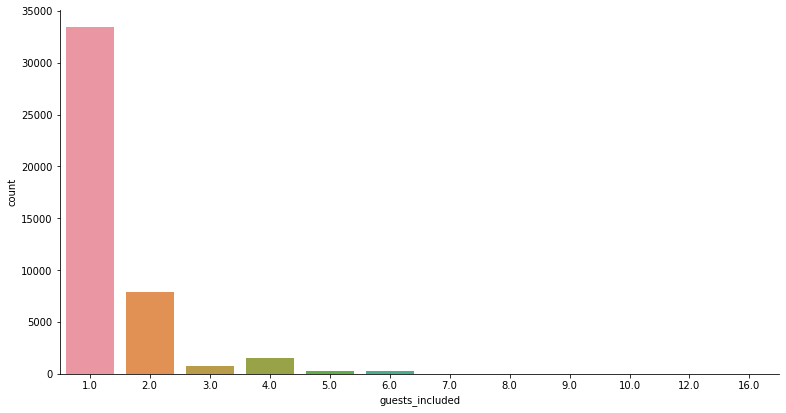

In [78]:
sns.catplot(x='guests_included', kind='count' ,data=train)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [79]:
#train:
train["one_guest"] = np.where(train["guests_included"] == 1, 1, 0)

#test:
test["one_guest"] = np.where(test["guests_included"] == 1, 1, 0)

In [80]:
corr = train[["guests_included", "one_guest", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,guests_included,one_guest,price
guests_included,1,-0.773365,0.271349
one_guest,-0.773365,1,-0.111195
price,0.271349,-0.111195,1


### 2.3.8 `extra_people`

In [81]:
train.extra_people.describe()

count    44153.000000
mean         5.407062
std         12.430647
min          0.000000
25%          0.000000
50%          0.000000
75%         10.000000
max        281.000000
Name: extra_people, dtype: float64

In [82]:
#train:
train["extra_people"] = train["extra_people"].fillna(0)

#test:
test["extra_people"] = test["extra_people"].fillna(0)

In [83]:
pd.crosstab(train.extra_people, train.price_range)

price_range,+200,100-150,150-200,50-100,< 50
extra_people,,,,,
0.0,1839,4364,1674,16035,7490
1.0,0,0,0,1,0
3.0,0,1,0,0,1
4.0,0,0,0,3,3
5.0,6,62,15,512,455
6.0,1,2,0,29,33
7.0,0,15,3,69,50
8.0,1,31,4,93,66
9.0,4,9,2,52,28


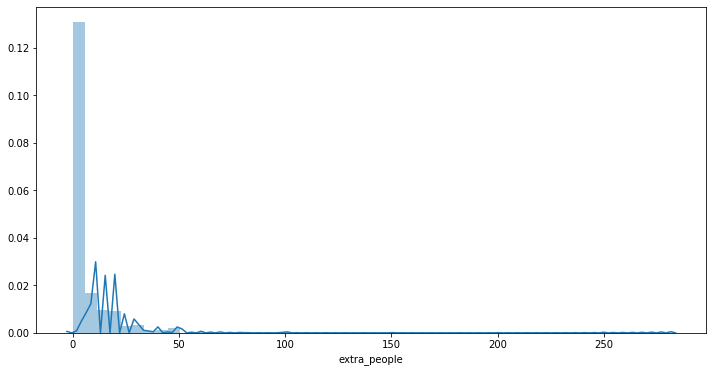

In [84]:
sns.distplot(train.extra_people)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [85]:
#train:
train["extra_people"] = np.log1p(train["extra_people"])

#test:
test["extra_people"] = np.log1p(test["extra_people"])

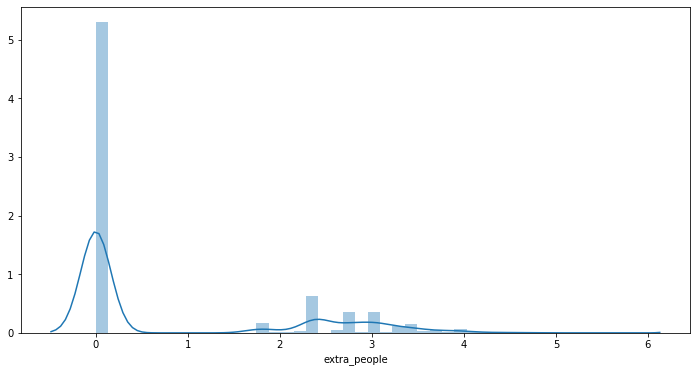

In [86]:
sns.distplot(train.extra_people)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [87]:
corr = train[["extra_people", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,extra_people,price
extra_people,1,0.0488629
price,0.0488629,1


### 2.3.9 `host_listings_count`

In [88]:
train.host_listings_count.describe()

count    44143.000000
mean         5.027637
std         22.527465
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        661.000000
Name: host_listings_count, dtype: float64

In [89]:
#train:
train["host_listings_count"] = train["host_listings_count"].fillna(1)

#test:
test["host_listings_count"] = test["host_listings_count"].fillna(1)

In [90]:
pd.crosstab(train["host_listings_count"], train.price_range)

price_range,+200,100-150,150-200,50-100,< 50
host_listings_count,,,,,
0.0,3,7,3,41,18
1.0,1118,4238,1280,17870,8231
2.0,325,742,253,2436,1358
3.0,122,230,91,637,317
4.0,58,122,63,267,103
5.0,36,80,29,137,58
6.0,41,59,24,85,51
7.0,36,43,23,91,35
8.0,16,30,17,36,11


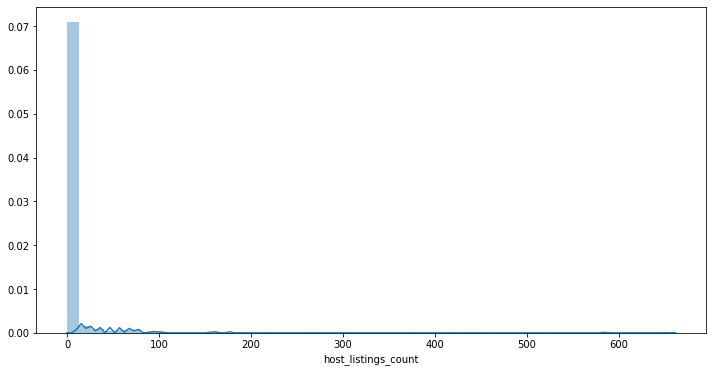

In [91]:
sns.distplot(train.host_listings_count)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [92]:
#train:
train["host_listings_count"] = np.log1p(train["host_listings_count"])

#test:
test["host_listings_count"] = np.log1p(test["host_listings_count"])

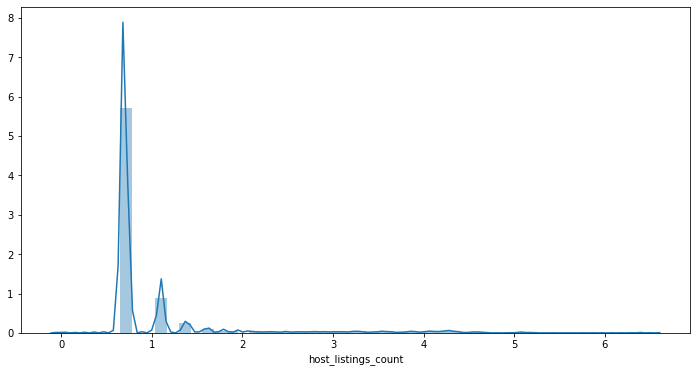

In [93]:
sns.distplot(train.host_listings_count)
fig = plt.gcf()
fig.set_size_inches(12, 6)

In [94]:
corr = train[["host_listings_count", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,host_listings_count,price
host_listings_count,1,0.295997
price,0.295997,1


### 2.3.10 `availability_365`

In [95]:
train.availability_365.describe()

count    44153.000000
mean       144.077503
std        140.806333
min          0.000000
25%          0.000000
50%         93.000000
75%        289.000000
max        365.000000
Name: availability_365, dtype: float64

In [96]:
#train:
train["availability_365"] = train["availability_365"].fillna(0.693147)

#test:
test["availability_365"] = test["availability_365"].fillna(0.693147)

(0, 365)

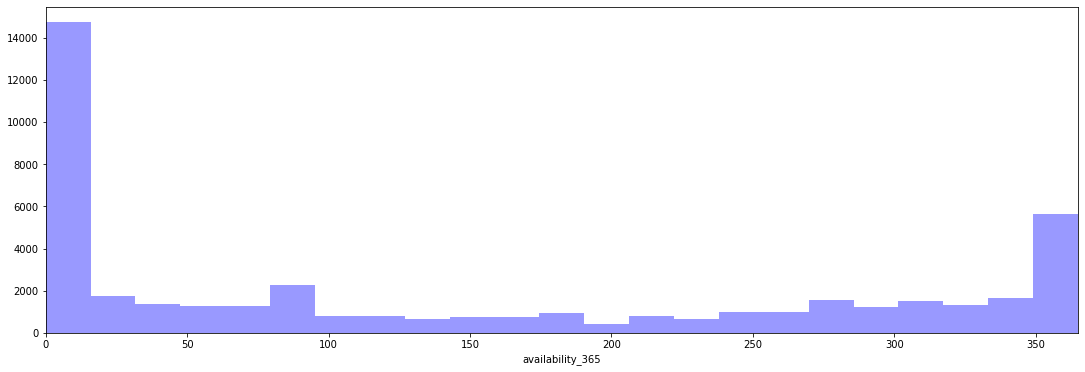

In [97]:
fig, axes = plt.subplots(1,1,figsize=(18.5, 6))
sns.distplot(train['availability_365'], rug=False, kde=False, color="blue", ax=axes)
axes.set_xlabel('availability_365')
axes.set_xlim(0, 365)

(0, 365)

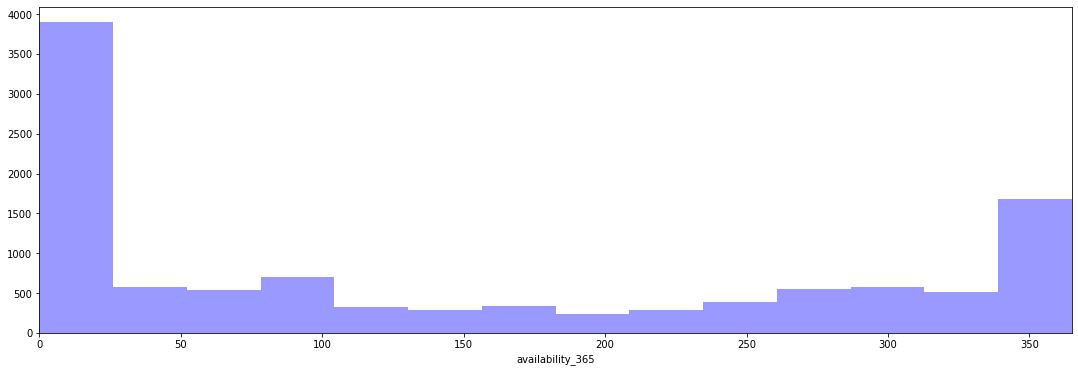

In [98]:
fig, axes = plt.subplots(1,1,figsize=(18.5, 6))
sns.distplot(test['availability_365'], rug=False, kde=False, color="blue", ax=axes)
axes.set_xlabel('availability_365')
axes.set_xlim(0, 365)

In [99]:
#train:
train['all_year_avail'] = np.where(train['availability_365'] > 350, 1, 0)
train['low_avail'] = np.where(train['availability_365'] < 16, 1, 0)

#test:
test['all_year_avail'] = np.where(test['availability_365'] > 338, 1, 0)
test['low_avail'] = np.where(test['availability_365']< 25, 1, 0)

In [100]:
corr = train[['all_year_avail', "low_avail", "price"]].corr()
corr.style.background_gradient(cmap='coolwarm')

,all_year_avail,low_avail,price
all_year_avail,1,-0.267731,0.0758469
low_avail,-0.267731,1,-0.167208
price,0.0758469,-0.167208,1


### 2.3.10 `reviews_per_month`

In [101]:
train.reviews_per_month.describe()

count    32906.000000
mean         1.167171
std          1.373956
min          0.010000
25%          0.270000
50%          0.670000
75%          1.530000
max         14.850000
Name: reviews_per_month, dtype: float64

In [102]:
test.reviews_per_month.describe()

count    8207.000000
mean        1.168294
std         1.393919
min         0.010000
25%         0.260000
50%         0.650000
75%         1.530000
max        18.000000
Name: reviews_per_month, dtype: float64

In [103]:
#train:
train["reviews_per_month"] = train["reviews_per_month"].fillna(0.67)

#test:
test["reviews_per_month"] = test["reviews_per_month"].fillna(0.65)

(0, 3)

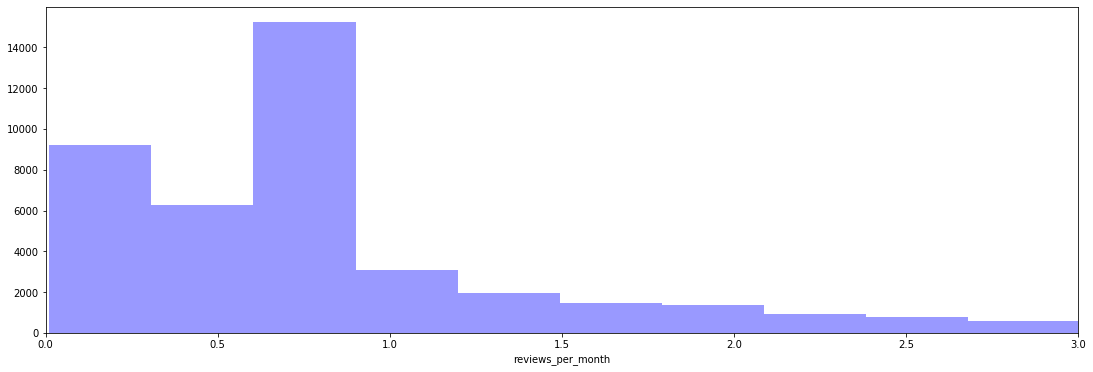

In [104]:
fig, axes = plt.subplots(1,1,figsize=(18.5, 6))
sns.distplot(train['reviews_per_month'], rug=False, kde=False, color="blue", ax=axes)
axes.set_xlabel('reviews_per_month')
axes.set_xlim(0, 3)

In [105]:
#train:
train["no_reviews"] = np.where(train["reviews_per_month"] == 0, 1, 0)

#test:
test["no_reviews"] = np.where(test["reviews_per_month"] == 0, 1, 0)

## 2.4 Defining distance from the center of Paris

In [106]:
train = train[~train.latitude_airbnb.isna()]
train = train[~train.longitude_airbnb.isna()]
train = train[~train.price.isna()]

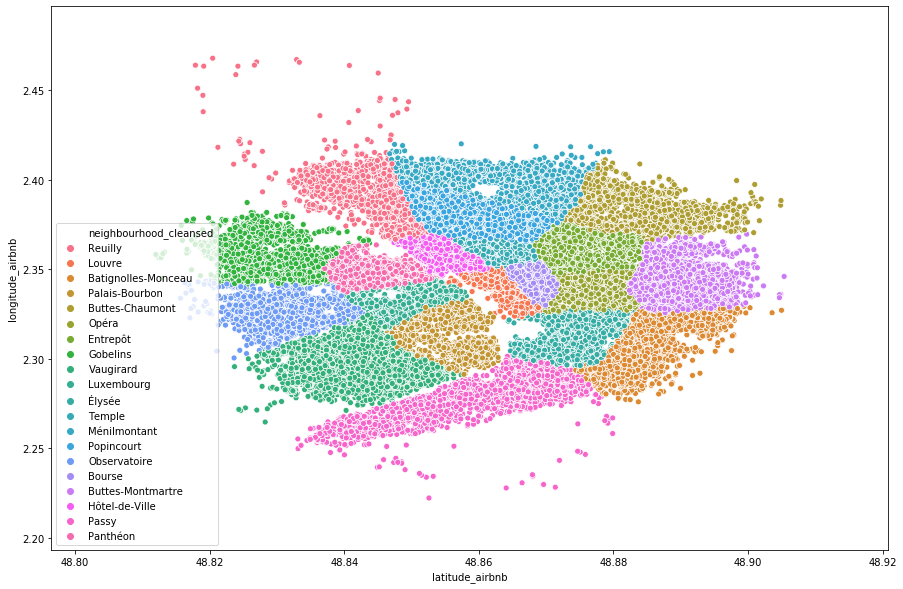

In [107]:
sns.scatterplot(x= train['latitude_airbnb'], y=train['longitude_airbnb'], hue=train.neighbourhood_cleansed)
fig = plt.gcf()
fig.set_size_inches(15, 10)

In [108]:
def center_dist(lat, lon):
    paris_st_louis = (48.8534, 2.3488)
    accommodation = (lat, lon)
    return great_circle(paris_st_louis, accommodation).km

def eiffel_dist(lat, lon):
    eiffel = (48.858093, 2.294694)
    accommodation = (lat, lon)
    return great_circle(eiffel, accommodation).km

def louvre_dist(lat, lon):
    paris_louvre = (48.864824, 2.334595)
    accommodation = (lat, lon)
    return great_circle(paris_louvre, accommodation).km

def notre_dame_dist(lat, lon):
    notre_dame = (48.852968, 2.349902)
    accommodation = (lat, lon)
    return great_circle(notre_dame, accommodation).km

def sacre_coeur_dist(lat, lon):
    sacre_coeur = (48.885907, 2.343151)
    accommodation = (lat, lon)
    return great_circle(sacre_coeur, accommodation).km

def CDG_dist(lat, lon):
    CDG = (49.0097, 2.5479)
    accommodation = (lat, lon)
    return great_circle(CDG, accommodation).km



#train:
train['dist_center'] = train.apply(lambda x: center_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
train['dist_louvre'] = train.apply(lambda x: louvre_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
train['dist_tour_eiffel'] = train.apply(lambda x: eiffel_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
train['dist_notre_dame'] = train.apply(lambda x: notre_dame_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
train['dist_sacre_coeur'] = train.apply(lambda x: sacre_coeur_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
train['dist_CDG'] = train.apply(lambda x: CDG_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)

#test:
test['dist_center'] = test.apply(lambda x: center_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
test['dist_louvre'] = test.apply(lambda x: louvre_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
test['dist_tour_eiffel'] = test.apply(lambda x: eiffel_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
test['dist_notre_dame'] = test.apply(lambda x: notre_dame_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
test['dist_CDG'] = test.apply(lambda x: CDG_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)
test['dist_sacre_coeur'] = test.apply(lambda x: sacre_coeur_dist(x.latitude_airbnb, x.longitude_airbnb), axis=1)

In [109]:
#train:
train['dist_monument'] = (train['dist_tour_eiffel'] + train['dist_notre_dame'] +
                          train['dist_sacre_coeur'] + train['dist_louvre'])/4

#test:
test['dist_monument'] = (test['dist_tour_eiffel'] + test['dist_notre_dame'] +
                         test['dist_sacre_coeur'] + test['dist_louvre'])/4

In [110]:
#train:
train["closer"] = train[['dist_louvre', 'dist_tour_eiffel',
                         'dist_notre_dame', 'dist_CDG', 'dist_sacre_coeur']].values.min(1)
train["closer_monument"] = np.log1p(train["closer"])

#test:
test["closer"] = test[['dist_louvre', 'dist_tour_eiffel',
                         'dist_notre_dame', 'dist_CDG', 'dist_sacre_coeur']].values.min(1)
test["closer_monument"] = np.log1p(test["closer"])

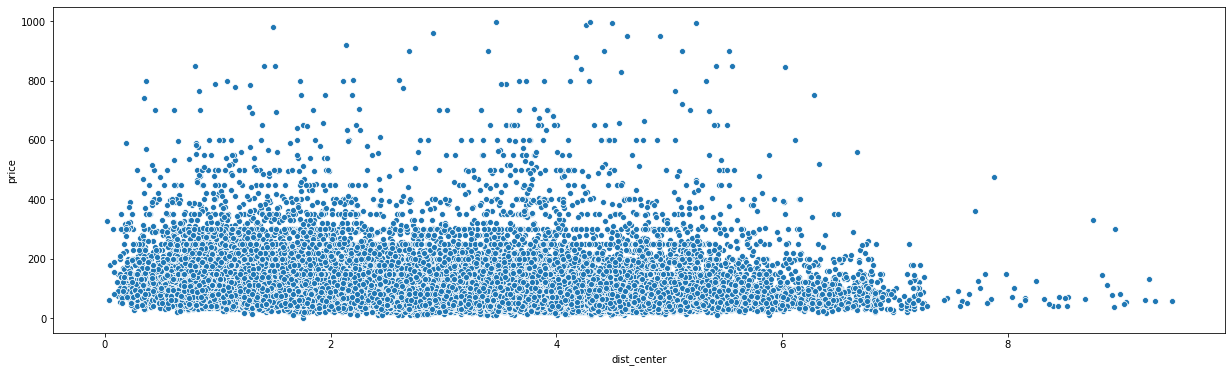

In [111]:
fig, axes = plt.subplots(1,1, figsize=(21,6))
sns.scatterplot(x= train['dist_center'], y=train['price'])

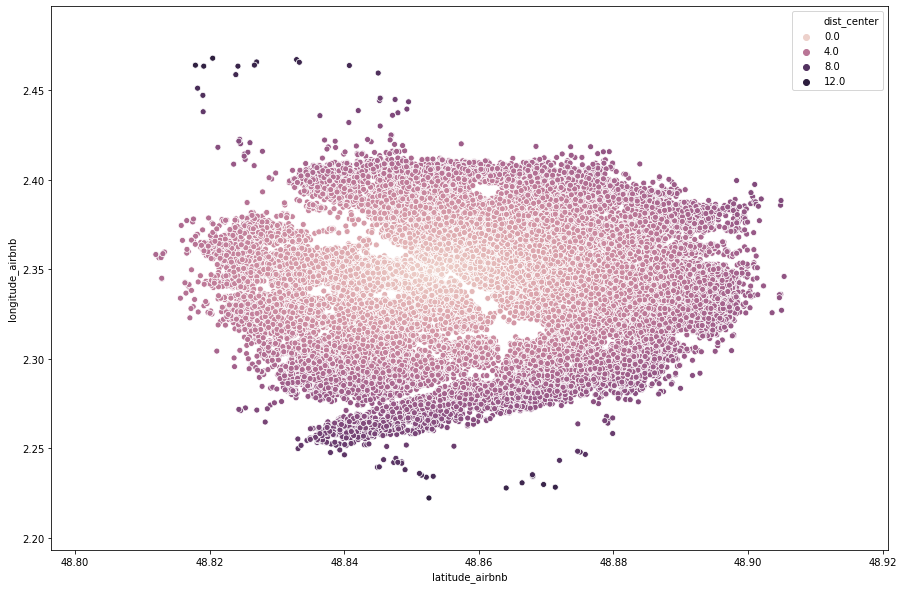

In [112]:
sns.scatterplot(x= train['latitude_airbnb'], y=train['longitude_airbnb'], hue=train.dist_center)
fig = plt.gcf()
fig.set_size_inches(15, 10)

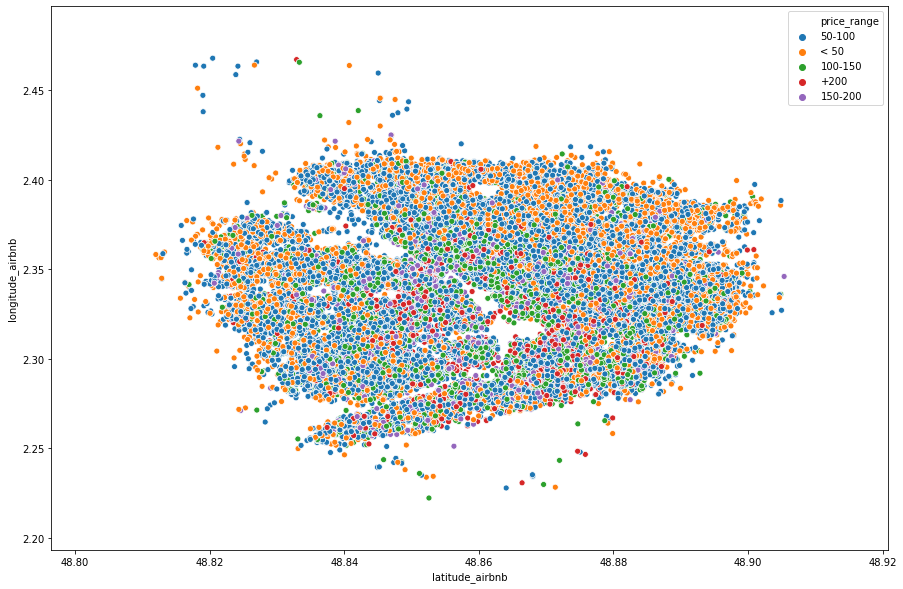

In [113]:
sns.scatterplot(x= train['latitude_airbnb'], y=train['longitude_airbnb'], hue=train.price_range)
fig = plt.gcf()
fig.set_size_inches(15, 10)

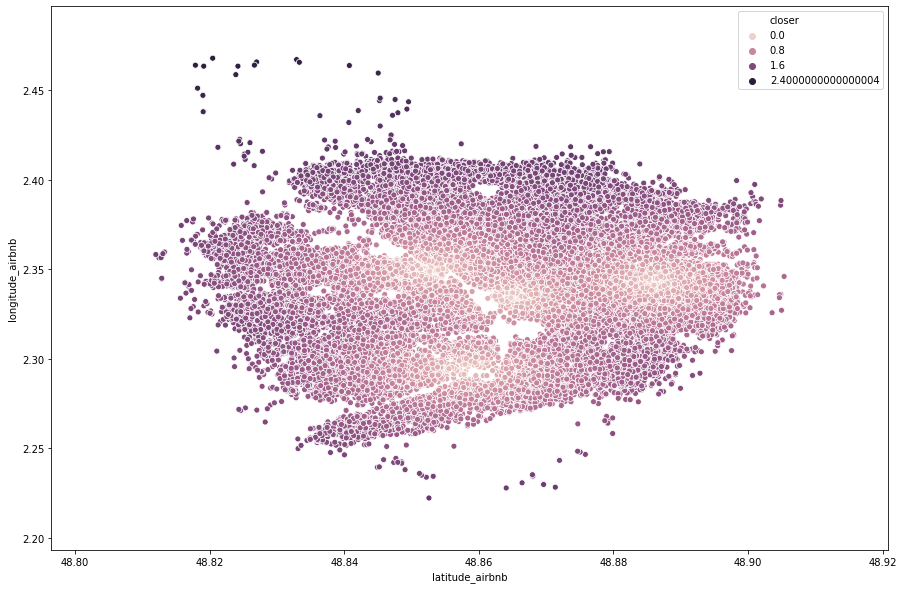

In [114]:
sns.scatterplot(x= train['latitude_airbnb'], y=train['longitude_airbnb'], hue=np.log1p(train.closer))
fig = plt.gcf()
fig.set_size_inches(15, 10)

## 2.6 Square meters (extracted from the description and the name)

We will extract all numbers from the `description`and `name` which are preceded by "s", "m", "S" or "M".

In [115]:
#train:
# extract numbers 
train['square_meters'] = train['description'].str.extract('(\d{2,3}\s?[smSM])', expand=True)
train['square_meters'] = train['square_meters'].str.replace("\D", "")
# change datatype of size into float
train['square_meters'] = train['square_meters'].astype(float)

print('train: NAs in square_meters:     ', train['square_meters'].isna().sum())
print('train: NAs in square_meters in percentage:', round(train['square_meters'].isna().sum()/len(train),3)*100, '%')

#test:
# extract numbers 
test['square_meters'] = test['description'].str.extract('(\d{2,3}\s?[smSM])', expand=True)
test['square_meters'] = test['square_meters'].str.replace("\D", "")

# change datatype of size into float
test['square_meters'] = test['square_meters'].astype(float)

print('test: NAs in square_meters:     ', test['square_meters'].isna().sum())
print('test: NAs in square_meters in percentage:', round(test['square_meters'].isna().sum()/len(test),3)*100, '%')

train: NAs in square_meters:      17513
train: NAs in square_meters in percentage: 39.7 %
test: NAs in square_meters:      4289
test: NAs in square_meters in percentage: 39.4 %


In [116]:
#train:
train['square_meters_name'] = train['name'].str.extract("(\d{2,3}\s[smSM])", expand=True)
train['square_meters_name'] = train['square_meters_name'].str.replace("\D", "").astype(float)

#test:
test['square_meters_name'] = test['name'].str.extract("(\d{2,3}\s[smSM])", expand=True)
test['square_meters_name'] = test['square_meters_name'].str.replace("\D", "").astype(float)

In [117]:
#updating the square_meters column with values extracted from column square_meters_name:

#train:
train.loc[(train['square_meters'] == 0)|(train['square_meters'] > 200), 'square_meters'] = train['square_meters_name']

#test:
test.loc[(test['square_meters'] == 0)|(test['square_meters'] > 200), 'square_meters'] = test['square_meters_name']

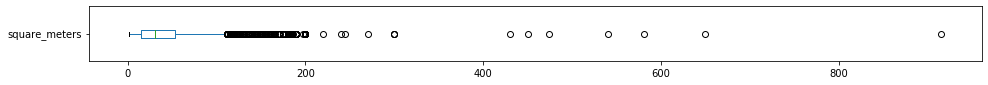

In [118]:
# Checking suspiciously high sizes:
train['square_meters'].plot(kind='box', vert=False, figsize=(16,1))

train.square_meters.replace(to_replace='', value=np.nan, inplace=True)

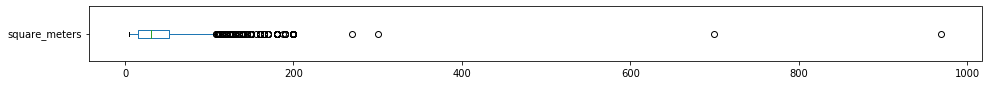

In [119]:
# Checking suspiciously high sizes:
test['square_meters'].plot(kind='box', vert=False, figsize=(16,1))

test.square_meters.replace(to_replace='', value=np.nan, inplace=True)

### 2.6.1 Features for the model

In [120]:
features_to_keep = ['features_score', 'Essentials', 'Iron', 'Cable TV', 'Dryer', 'Laptop friendly workspace',
'Real_Bed', 'Pull-out_Sofa', 'Apartment', 'House_Loft', 'Entire home/apt', 'Private room',
'flexible', 'moderate','strict', 'Reuilly', 'Louvre', 'Batignolles-Monceau', 'Palais-Bourbon',
'Buttes-Chaumont', 'Opéra', 'Entrepôt', 'Gobelins', 'Vaugirard','Luxembourg', 'Élysée',
'Temple', 'Ménilmontant', 'Popincourt','Observatoire', 'Bourse', 'Buttes-Montmartre', 'Hôtel-de-Ville',
'Passy', 'Panthéon', 'secu_score', 'clean_score', "beds", "one_bed", "bathrooms", "one_bath", "accommodates",
"low_acco", "high_acco", "bedrooms", "one_bedroom", 'minimum_nights', "guests_included", "one_guest",
"extra_people", "host_listings_count", "availability_365", 'all_year_avail', 'low_avail', "reviews_per_month",
"no_reviews", 'dist_center', 'dist_louvre', 'dist_tour_eiffel', 'dist_notre_dame', 'dist_sacre_coeur', 'dist_CDG',
"dist_monument", "closer_monument", "latitude_airbnb", "longitude_airbnb", "square_meters", "price"]

features_to_keep_test = ['features_score', 'Essentials', 'Iron', 'Cable TV', 'Dryer', 'Laptop friendly workspace',
'Real_Bed', 'Pull-out_Sofa', 'Apartment', 'House_Loft', 'Entire home/apt', 'Private room',
'flexible', 'moderate','strict', 'Reuilly', 'Louvre', 'Batignolles-Monceau', 'Palais-Bourbon',
'Buttes-Chaumont', 'Opéra', 'Entrepôt', 'Gobelins', 'Vaugirard','Luxembourg', 'Élysée',
'Temple', 'Ménilmontant', 'Popincourt','Observatoire', 'Bourse', 'Buttes-Montmartre', 'Hôtel-de-Ville',
'Passy', 'Panthéon', 'secu_score', 'clean_score', "beds", "one_bed", "bathrooms", "one_bath", "accommodates",
"low_acco", "high_acco", "bedrooms", "one_bedroom", 'minimum_nights', "guests_included", "one_guest",
"extra_people", "host_listings_count", "availability_365", 'all_year_avail', 'low_avail', "reviews_per_month",
"no_reviews", 'dist_center', 'dist_louvre', 'dist_tour_eiffel', 'dist_notre_dame', 'dist_sacre_coeur', 'dist_CDG',
"dist_monument", "closer_monument", "latitude_airbnb", "longitude_airbnb", "square_meters"]

In [121]:
#train:
train_bis = train[features_to_keep]

#test:
test_bis = test[features_to_keep_test]

### 2.6.3 Linear regression: predicting missing values for the `square_meters` variable

In [122]:
#train:
model_train_sq = sm.OLS(train_bis[~train_bis.square_meters.isna()].square_meters,
               train_bis.loc[:,~train_bis.columns.isin(["square_meters", "price"])][~train_bis.square_meters.isna()])
model_train_sq = model_train_sq.fit()

#test:
model_test_sq = sm.OLS(test_bis[~test_bis.square_meters.isna()].square_meters,
               test_bis.loc[:,~test_bis.columns.isin(["square_meters"])][~test_bis.square_meters.isna()])
model_test_sq = model_test_sq.fit()

In [123]:
#Predicting square_meters:

#train:
train_bis.square_meters = train_bis.square_meters.fillna(
    model_train_sq.predict(train_bis.loc[:,~train_bis.columns.isin(["square_meters", "price"])]
                                                                  [train_bis.square_meters.isna()]))

#test:
test_bis.square_meters = test_bis.square_meters.fillna(
    model_test_sq.predict(test_bis.loc[:,~test_bis.columns.isin(["square_meters"])]
                                                                  [test_bis.square_meters.isna()]))

`square_meters` transformation to $log(1 + $`square_meters`):

In [124]:
#square_meters transformation to 
train_bis["square_meters"] = np.log1p(train_bis["square_meters"])

test_bis["square_meters"] = np.log1p(test_bis["square_meters"])

(0, 200)

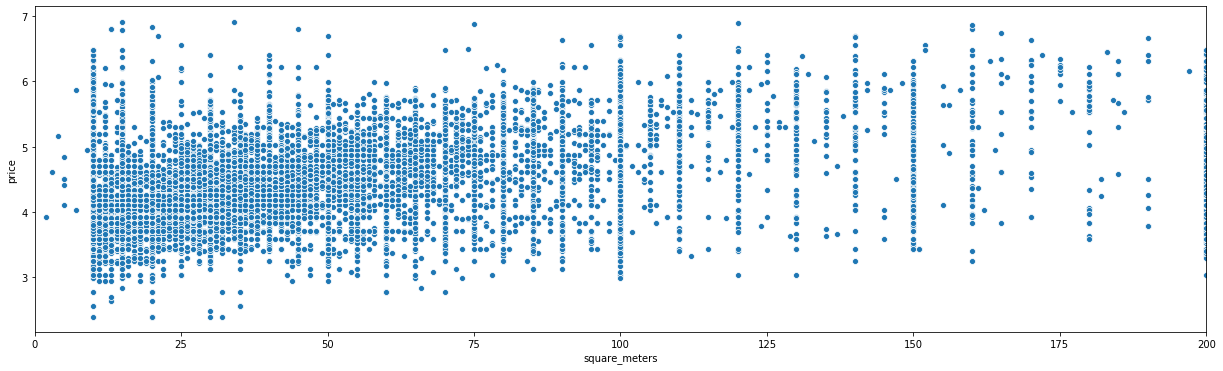

In [125]:
fig, axes = plt.subplots(1,1, figsize=(21,6))
sns.scatterplot(x= train['square_meters'], y=np.log1p(train['price']))
axes.set_xlim(0, 200)

# 3 Predicting the price

In [139]:
#train:
new_train = train_bis.copy()

#test:
new_test = test_bis.copy()

In [140]:
#Label and features:
features = new_train.drop("price", axis = 1)
label = np.log1p(new_train["price"])

In [141]:
#Splitting into train and validation:
X_train, X_valid, y_train, y_valid = train_test_split(features, label, test_size=0.2, random_state = 42)

## 3.1 Gradient Boosting Algorithm

In [142]:
#Standardization:
sc = RobustScaler()

#train:
X_train_n = sc.fit_transform(X_train)
X_valid_n  = sc.transform(X_valid)
features_n = sc.transform(features)

#test:
new_test_n = sc.transform(new_test)

In [153]:
#CatBoost algorithm:
model = CatBoostRegressor(iterations=5000, 
                          depth=6, 
                          learning_rate=0.05, 
                          loss_function='RMSE',
                          bootstrap_type = "Bayesian")

model.fit(X_train_n, y_train)

#on the validation set:
preds_valid = np.exp(model.predict(X_valid_n)) -1 
mse_valid = mean_squared_error(np.exp(y_valid)-1, preds_valid)
rmse_valid = np.sqrt(mse_valid)

#on the train set:
preds_train = np.exp(model.predict(X_train_n))-1
mse_train = mean_squared_error(np.exp(y_train)-1, preds_train)
rmse_train = np.sqrt(mse_train)


print("MSE test: %f" % (mse_valid))
print("RMSE test: %f" % (rmse_valid))
print("MSE valid: %f" % (mse_train))
print("RMSE valid: %f" % (rmse_train))

0:	learn: 0.5400114	total: 20.5ms	remaining: 1m 42s
1:	learn: 0.5262647	total: 34.2ms	remaining: 1m 25s
2:	learn: 0.5138418	total: 44.7ms	remaining: 1m 14s
3:	learn: 0.5015722	total: 54.9ms	remaining: 1m 8s
4:	learn: 0.4902346	total: 64.8ms	remaining: 1m 4s
5:	learn: 0.4799395	total: 75.3ms	remaining: 1m 2s
6:	learn: 0.4703288	total: 85ms	remaining: 1m
7:	learn: 0.4610387	total: 97.2ms	remaining: 1m
8:	learn: 0.4522119	total: 109ms	remaining: 1m
9:	learn: 0.4436797	total: 119ms	remaining: 59.4s
10:	learn: 0.4361726	total: 129ms	remaining: 58.4s
11:	learn: 0.4287111	total: 139ms	remaining: 57.6s
12:	learn: 0.4216104	total: 148ms	remaining: 56.9s
13:	learn: 0.4151300	total: 158ms	remaining: 56.3s
14:	learn: 0.4092986	total: 168ms	remaining: 55.8s
15:	learn: 0.4034465	total: 178ms	remaining: 55.3s
16:	learn: 0.3981750	total: 188ms	remaining: 55s
17:	learn: 0.3930037	total: 198ms	remaining: 54.7s
18:	learn: 0.3885501	total: 208ms	remaining: 54.5s
19:	learn: 0.3843700	total: 217ms	remaining

172:	learn: 0.2851691	total: 2.08s	remaining: 58s
173:	learn: 0.2850375	total: 2.09s	remaining: 58s
174:	learn: 0.2849462	total: 2.1s	remaining: 57.9s
175:	learn: 0.2848432	total: 2.11s	remaining: 57.9s
176:	learn: 0.2847418	total: 2.12s	remaining: 57.9s
177:	learn: 0.2846368	total: 2.14s	remaining: 57.9s
178:	learn: 0.2845433	total: 2.15s	remaining: 57.9s
179:	learn: 0.2844420	total: 2.16s	remaining: 57.8s
180:	learn: 0.2843378	total: 2.17s	remaining: 57.8s
181:	learn: 0.2842685	total: 2.18s	remaining: 57.7s
182:	learn: 0.2841261	total: 2.19s	remaining: 57.7s
183:	learn: 0.2840523	total: 2.2s	remaining: 57.6s
184:	learn: 0.2838994	total: 2.22s	remaining: 57.7s
185:	learn: 0.2838037	total: 2.23s	remaining: 57.7s
186:	learn: 0.2836914	total: 2.25s	remaining: 57.8s
187:	learn: 0.2836391	total: 2.26s	remaining: 57.9s
188:	learn: 0.2835799	total: 2.28s	remaining: 58s
189:	learn: 0.2834831	total: 2.29s	remaining: 58.1s
190:	learn: 0.2833693	total: 2.31s	remaining: 58.1s
191:	learn: 0.283300

338:	learn: 0.2735107	total: 4.75s	remaining: 1m 5s
339:	learn: 0.2734759	total: 4.77s	remaining: 1m 5s
340:	learn: 0.2734280	total: 4.79s	remaining: 1m 5s
341:	learn: 0.2733975	total: 4.81s	remaining: 1m 5s
342:	learn: 0.2733491	total: 4.83s	remaining: 1m 5s
343:	learn: 0.2732976	total: 4.85s	remaining: 1m 5s
344:	learn: 0.2732321	total: 4.87s	remaining: 1m 5s
345:	learn: 0.2731610	total: 4.89s	remaining: 1m 5s
346:	learn: 0.2730783	total: 4.91s	remaining: 1m 5s
347:	learn: 0.2730402	total: 4.93s	remaining: 1m 5s
348:	learn: 0.2729741	total: 4.96s	remaining: 1m 6s
349:	learn: 0.2729137	total: 4.97s	remaining: 1m 6s
350:	learn: 0.2728568	total: 4.99s	remaining: 1m 6s
351:	learn: 0.2728385	total: 5.01s	remaining: 1m 6s
352:	learn: 0.2727990	total: 5.02s	remaining: 1m 6s
353:	learn: 0.2727553	total: 5.03s	remaining: 1m 5s
354:	learn: 0.2727255	total: 5.04s	remaining: 1m 5s
355:	learn: 0.2726872	total: 5.05s	remaining: 1m 5s
356:	learn: 0.2726454	total: 5.06s	remaining: 1m 5s
357:	learn: 

507:	learn: 0.2658825	total: 7.44s	remaining: 1m 5s
508:	learn: 0.2658569	total: 7.46s	remaining: 1m 5s
509:	learn: 0.2658206	total: 7.47s	remaining: 1m 5s
510:	learn: 0.2657688	total: 7.49s	remaining: 1m 5s
511:	learn: 0.2657117	total: 7.5s	remaining: 1m 5s
512:	learn: 0.2656471	total: 7.51s	remaining: 1m 5s
513:	learn: 0.2656111	total: 7.52s	remaining: 1m 5s
514:	learn: 0.2655591	total: 7.53s	remaining: 1m 5s
515:	learn: 0.2655365	total: 7.54s	remaining: 1m 5s
516:	learn: 0.2655049	total: 7.56s	remaining: 1m 5s
517:	learn: 0.2654671	total: 7.57s	remaining: 1m 5s
518:	learn: 0.2654378	total: 7.59s	remaining: 1m 5s
519:	learn: 0.2653968	total: 7.61s	remaining: 1m 5s
520:	learn: 0.2653642	total: 7.63s	remaining: 1m 5s
521:	learn: 0.2653276	total: 7.66s	remaining: 1m 5s
522:	learn: 0.2652837	total: 7.68s	remaining: 1m 5s
523:	learn: 0.2652320	total: 7.69s	remaining: 1m 5s
524:	learn: 0.2651847	total: 7.71s	remaining: 1m 5s
525:	learn: 0.2651411	total: 7.72s	remaining: 1m 5s
526:	learn: 0

667:	learn: 0.2598138	total: 9.73s	remaining: 1m 3s
668:	learn: 0.2597775	total: 9.75s	remaining: 1m 3s
669:	learn: 0.2597538	total: 9.78s	remaining: 1m 3s
670:	learn: 0.2597249	total: 9.8s	remaining: 1m 3s
671:	learn: 0.2596841	total: 9.82s	remaining: 1m 3s
672:	learn: 0.2596420	total: 9.83s	remaining: 1m 3s
673:	learn: 0.2596293	total: 9.86s	remaining: 1m 3s
674:	learn: 0.2596059	total: 9.88s	remaining: 1m 3s
675:	learn: 0.2595799	total: 9.89s	remaining: 1m 3s
676:	learn: 0.2595327	total: 9.91s	remaining: 1m 3s
677:	learn: 0.2595091	total: 9.93s	remaining: 1m 3s
678:	learn: 0.2594717	total: 9.96s	remaining: 1m 3s
679:	learn: 0.2594446	total: 9.98s	remaining: 1m 3s
680:	learn: 0.2594191	total: 10s	remaining: 1m 3s
681:	learn: 0.2593876	total: 10s	remaining: 1m 3s
682:	learn: 0.2593682	total: 10s	remaining: 1m 3s
683:	learn: 0.2593481	total: 10.1s	remaining: 1m 3s
684:	learn: 0.2593123	total: 10.1s	remaining: 1m 3s
685:	learn: 0.2592736	total: 10.1s	remaining: 1m 3s
686:	learn: 0.25922

...

4336:	learn: 0.1857968	total: 58.5s	remaining: 8.95s
4337:	learn: 0.1857778	total: 58.5s	remaining: 8.93s
4338:	learn: 0.1857597	total: 58.5s	remaining: 8.92s
4339:	learn: 0.1857476	total: 58.6s	remaining: 8.9s
4340:	learn: 0.1857300	total: 58.6s	remaining: 8.89s
4341:	learn: 0.1857189	total: 58.6s	remaining: 8.88s
4342:	learn: 0.1857059	total: 58.6s	remaining: 8.86s
4343:	learn: 0.1856905	total: 58.6s	remaining: 8.85s
4344:	learn: 0.1856726	total: 58.6s	remaining: 8.84s
4345:	learn: 0.1856586	total: 58.6s	remaining: 8.82s
4346:	learn: 0.1856466	total: 58.6s	remaining: 8.81s
4347:	learn: 0.1856316	total: 58.6s	remaining: 8.79s
4348:	learn: 0.1856148	total: 58.7s	remaining: 8.78s
4349:	learn: 0.1856013	total: 58.7s	remaining: 8.77s
4350:	learn: 0.1855746	total: 58.7s	remaining: 8.75s
4351:	learn: 0.1855613	total: 58.7s	remaining: 8.74s
4352:	learn: 0.1855404	total: 58.7s	remaining: 8.72s
4353:	learn: 0.1855327	total: 58.7s	remaining: 8.71s
4354:	learn: 0.1855175	total: 58.7s	remaining: 

4500:	learn: 0.1834754	total: 1m	remaining: 6.69s
4501:	learn: 0.1834684	total: 1m	remaining: 6.68s
4502:	learn: 0.1834548	total: 1m	remaining: 6.67s
4503:	learn: 0.1834369	total: 1m	remaining: 6.65s
4504:	learn: 0.1834183	total: 1m	remaining: 6.64s
4505:	learn: 0.1834011	total: 1m	remaining: 6.62s
4506:	learn: 0.1833797	total: 1m	remaining: 6.61s
4507:	learn: 0.1833677	total: 1m	remaining: 6.6s
4508:	learn: 0.1833609	total: 1m	remaining: 6.58s
4509:	learn: 0.1833514	total: 1m	remaining: 6.57s
4510:	learn: 0.1833395	total: 1m	remaining: 6.56s
4511:	learn: 0.1833198	total: 1m	remaining: 6.54s
4512:	learn: 0.1833024	total: 1m	remaining: 6.53s
4513:	learn: 0.1832883	total: 1m	remaining: 6.51s
4514:	learn: 0.1832725	total: 1m	remaining: 6.5s
4515:	learn: 0.1832581	total: 1m	remaining: 6.49s
4516:	learn: 0.1832460	total: 1m	remaining: 6.47s
4517:	learn: 0.1832352	total: 1m	remaining: 6.46s
4518:	learn: 0.1832122	total: 1m	remaining: 6.45s
4519:	learn: 0.1831947	total: 1m	remaining: 6.43s
45

4668:	learn: 0.1811766	total: 1m 2s	remaining: 4.41s
4669:	learn: 0.1811593	total: 1m 2s	remaining: 4.4s
4670:	learn: 0.1811418	total: 1m 2s	remaining: 4.38s
4671:	learn: 0.1811321	total: 1m 2s	remaining: 4.37s
4672:	learn: 0.1811181	total: 1m 2s	remaining: 4.36s
4673:	learn: 0.1811035	total: 1m 2s	remaining: 4.34s
4674:	learn: 0.1810937	total: 1m 2s	remaining: 4.33s
4675:	learn: 0.1810846	total: 1m 2s	remaining: 4.32s
4676:	learn: 0.1810721	total: 1m 2s	remaining: 4.3s
4677:	learn: 0.1810473	total: 1m 2s	remaining: 4.29s
4678:	learn: 0.1810296	total: 1m 2s	remaining: 4.28s
4679:	learn: 0.1810140	total: 1m 2s	remaining: 4.26s
4680:	learn: 0.1810006	total: 1m 2s	remaining: 4.25s
4681:	learn: 0.1809830	total: 1m 2s	remaining: 4.24s
4682:	learn: 0.1809715	total: 1m 2s	remaining: 4.22s
4683:	learn: 0.1809630	total: 1m 2s	remaining: 4.21s
4684:	learn: 0.1809460	total: 1m 2s	remaining: 4.19s
4685:	learn: 0.1809318	total: 1m 2s	remaining: 4.18s
4686:	learn: 0.1809129	total: 1m 2s	remaining: 4

4836:	learn: 0.1789231	total: 1m 4s	remaining: 2.16s
4837:	learn: 0.1789095	total: 1m 4s	remaining: 2.15s
4838:	learn: 0.1788972	total: 1m 4s	remaining: 2.13s
4839:	learn: 0.1788835	total: 1m 4s	remaining: 2.12s
4840:	learn: 0.1788777	total: 1m 4s	remaining: 2.11s
4841:	learn: 0.1788622	total: 1m 4s	remaining: 2.09s
4842:	learn: 0.1788564	total: 1m 4s	remaining: 2.08s
4843:	learn: 0.1788434	total: 1m 4s	remaining: 2.07s
4844:	learn: 0.1788280	total: 1m 4s	remaining: 2.05s
4845:	learn: 0.1788097	total: 1m 4s	remaining: 2.04s
4846:	learn: 0.1787949	total: 1m 4s	remaining: 2.03s
4847:	learn: 0.1787853	total: 1m 4s	remaining: 2.01s
4848:	learn: 0.1787709	total: 1m 4s	remaining: 2s
4849:	learn: 0.1787602	total: 1m 4s	remaining: 1.99s
4850:	learn: 0.1787513	total: 1m 4s	remaining: 1.97s
4851:	learn: 0.1787422	total: 1m 4s	remaining: 1.96s
4852:	learn: 0.1787298	total: 1m 4s	remaining: 1.95s
4853:	learn: 0.1787173	total: 1m 4s	remaining: 1.93s
4854:	learn: 0.1787078	total: 1m 4s	remaining: 1.

MSE test: 1587.002693
RMSE test: 39.837202
MSE valid: 512.628964
RMSE valid: 22.641311


In [132]:
#Boosting algorithm with the XGBoost interface
#By hyper-parametrization we obtained max_depth = 5, learning_rate = 0.05:
xg_price = xgb.XGBRegressor(objective = "reg:squarederror", learning_rate = 0.05, colsample_bytree = 0.4, 
                           max_depth = 5 , n_estimators = 1000 , booster='gbtree')
xg_price.fit(X_train_n, y_train)

#on the validation set:
preds_valid = np.exp(xg_price.predict(X_valid_n)) -1 
mse_valid = mean_squared_error(np.exp(y_valid)-1, preds_valid)
rmse_valid = np.sqrt(mse_valid)

#on the train set:
preds_train = np.exp(xg_price.predict(X_train_n))-1
mse_train = mean_squared_error(np.exp(y_train)-1, preds_train)
rmse_train = np.sqrt(mse_train)


print("MSE test: %f" % (mse_valid))
print("RMSE test: %f" % (rmse_valid))
print("MSE valid: %f" % (mse_train))
print("RMSE valid: %f" % (rmse_train))

MSE test: 1542.205492
RMSE test: 39.270924
MSE valid: 1060.438258
RMSE valid: 32.564371


In [ ]:
pd.Series(preds_valid[0:20])

In [ ]:
np.exp(y_valid[0:20])-1

In [ ]:
#Variable importance:
plt.rcParams['figure.figsize'] = [8, 12]
xgb.plot_importance(xg_price)
plt.show()

# 4 Predictions on test data

## 4.1 Data processing, cleaning, feature transformations

In [ ]:
preds_test = np.exp(model.predict(new_test_n))-1

In [ ]:
#DataFrame:
pred_test = pd.DataFrame({"Id" : test.id,
                         "Predicted" : preds_test})
#To csv:
pred_test.to_csv("submit_catboost.csv", sep = ",", header = True, index = None)
pred_test

# Conclusion

Idea: we can improve the prediction accuracy hence the RMSE by doing deeper cross-validation, finding other features (maybe trickier ?) would have led to a decrease of the RMSE.